✅ Dataset loaded. Original columns: ['Have_Violation', 'Base_Reviews', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6']

Class distribution (original):
Human Values Violation
1    11127
0     7106
Name: count, dtype: int64


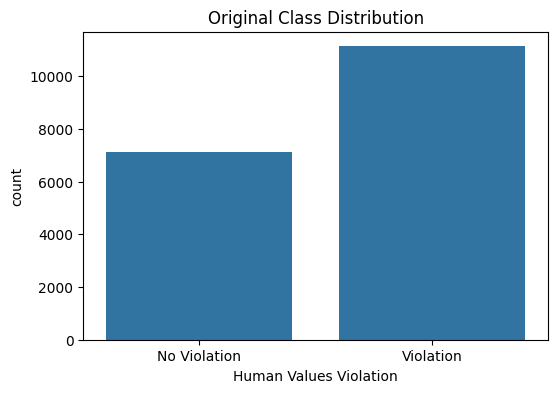


📊 Dataset Splits:
→ Full Train (for CV): 15498 samples
→ Held-Out Test: 2735 samples
→ Train class (raw): Counter({np.int64(1): 9458, np.int64(0): 6040}) | Test: Counter({1: 1669, 0: 1066})
Using device: cuda

🚀 Starting 5-Fold CV...

▶️  FOLD 1/5
Fold 1 → Train: 15132 (oversampled), Val: 3100
  → Train classes: Counter({1: 7566, 0: 7566}) | Val: Counter({np.int64(1): 1892, np.int64(0): 1208})
Epoch 1/6 | Train Acc: 0.8997 | Val Acc: 0.9329
Epoch 2/6 | Train Acc: 0.9596 | Val Acc: 0.9406
Epoch 3/6 | Train Acc: 0.9768 | Val Acc: 0.9384
Epoch 4/6 | Train Acc: 0.9845 | Val Acc: 0.9403
Epoch 5/6 | Train Acc: 0.9894 | Val Acc: 0.9429
Epoch 6/6 | Train Acc: 0.9904 | Val Acc: 0.9416

▶️  FOLD 2/5
Fold 2 → Train: 15132 (oversampled), Val: 3100
  → Train classes: Counter({1: 7566, 0: 7566}) | Val: Counter({np.int64(1): 1892, np.int64(0): 1208})
Epoch 1/6 | Train Acc: 0.8947 | Val Acc: 0.9174
Epoch 2/6 | Train Acc: 0.9577 | Val Acc: 0.9384
Epoch 3/6 | Train Acc: 0.9777 | Val Acc: 0.9410
Epoch 4

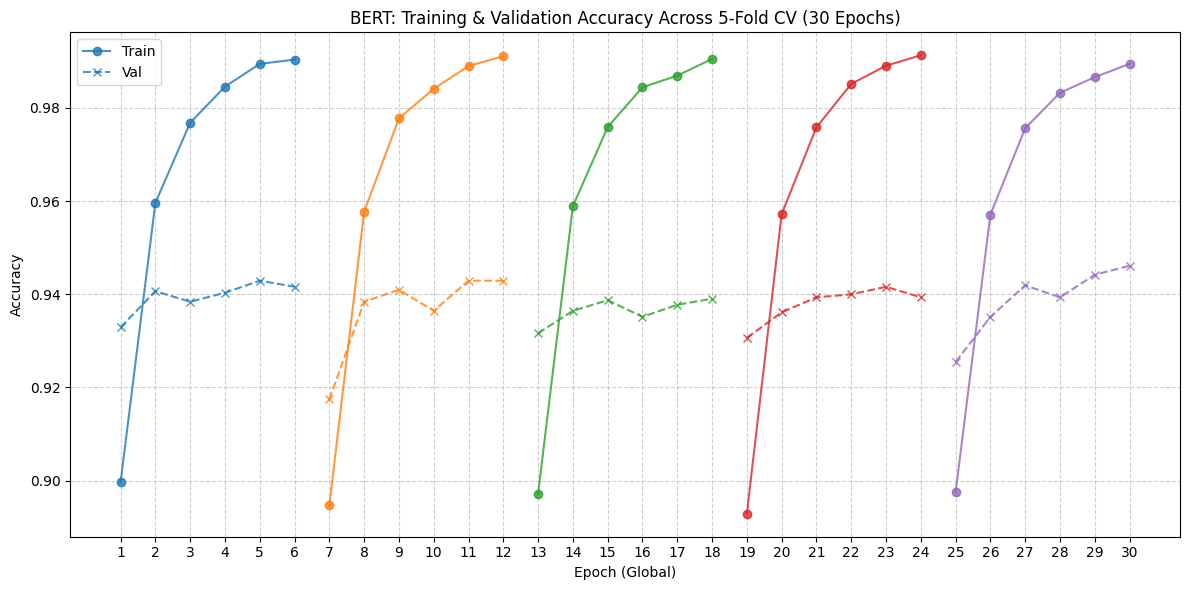


🎯 Retraining final model on FULL TRAIN...


ValueError: not enough values to unpack (expected 2, got 0)

In [ ]:
## BERT Binary Classification with 5-Fold CV + Final Learning Curves
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_fscore_support)
import re
from bs4 import BeautifulSoup
import contractions
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from copy import deepcopy

# ----------------------------
# 1. Load & Inspect Dataset
# ----------------------------
try:
    df = pd.read_csv('amazonbinaryclassificationdataset_transformer.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('amazonbinaryclassificationdataset_transformer.csv', encoding='latin1')

print("✅ Dataset loaded. Original columns:", df.columns.tolist())

df = df.rename(columns={'Base_Reviews': 'Review', 'Have_Violation': 'Human Values Violation'})

def convert_issue(issue):
    issue = str(issue).lower().strip()
    return 0 if issue in ['no', '0'] else 1

df['Human Values Violation'] = df['Human Values Violation'].apply(convert_issue)
df['Review'] = df['Review'].fillna('')

print("\nClass distribution (original):")
print(df['Human Values Violation'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Human Values Violation')
plt.title('Original Class Distribution')
plt.xticks([0, 1], ['No Violation', 'Violation'])
plt.show()

# ----------------------------
# 2. Preprocessing
# ----------------------------
def preprocess_review(text):
    if not isinstance(text, str):
        text = str(text)
    text = contractions.fix(text)
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = ' '.join(text.split())
    return text

df['ReviewP'] = df['Review'].apply(preprocess_review)
texts = df['ReviewP'].tolist()
labels = df['Human Values Violation'].tolist()

# ----------------------------
# 3. Train/Test Split
# ----------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.15, random_state=42, stratify=labels
)
X_train_raw, y_train_raw = np.array(X_temp), np.array(y_temp)

print(f"\n📊 Dataset Splits:")
print(f"→ Full Train (for CV): {len(X_train_raw)} samples")
print(f"→ Held-Out Test: {len(X_test)} samples")
print(f"→ Train class (raw): {Counter(y_train_raw)} | Test: {Counter(y_test)}")

# ----------------------------
# 4. Dataset & Model
# ----------------------------
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label)
        }

class BERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0]
        x = self.dropout(cls_output)
        logits = self.fc(x)
        return logits

# ----------------------------
# 5. Hyperparameters
# ----------------------------
model_name = "/root/.ssh/MyDeepLearning-Experiment/models/bert-base-uncased"
num_classes = 2
max_length = 128
batch_size = 16
num_epochs = 6
learning_rate = 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = BertTokenizer.from_pretrained(model_name)

# ----------------------------
# 6. 5-Fold CV
# ----------------------------
print("\n🚀 Starting 5-Fold CV...")

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
cv_results = []
all_train_accuracies = []
all_val_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_raw, y_train_raw), 1):
    print(f"\n{'='*50}\n▶️  FOLD {fold}/{k_folds}\n{'='*50}")

    X_tr, X_val = X_train_raw[train_idx], X_train_raw[val_idx]
    y_tr, y_val = y_train_raw[train_idx], y_train_raw[val_idx]

    ros = RandomOverSampler(random_state=42)
    X_tr_res, y_tr_res = ros.fit_resample(X_tr.reshape(-1, 1), y_tr)
    X_tr_res, y_tr_res = X_tr_res.flatten().tolist(), y_tr_res.tolist()

    print(f"Fold {fold} → Train: {len(X_tr_res)} (oversampled), Val: {len(X_val)}")
    print(f"  → Train classes: {Counter(y_tr_res)} | Val: {Counter(y_val)}")

    train_dataset = TextClassificationDataset(X_tr_res, y_tr_res, tokenizer, max_length)
    val_dataset = TextClassificationDataset(X_val.tolist(), y_val.tolist(), tokenizer, max_length)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = BERTClassifier(model_name, num_classes).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
    criterion = nn.CrossEntropyLoss()

    fold_train_accs = []
    fold_val_accs = []
    best_val_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        # Train
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        fold_train_accs.append(train_acc)

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids, attention_mask)
                preds = outputs.argmax(dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        val_acc = accuracy_score(val_true, val_preds)
        fold_val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    all_train_accuracies.append(fold_train_accs)
    all_val_accuracies.append(fold_val_accs)

    model.load_state_dict(best_state)
    precision, recall, f1, _ = precision_recall_fscore_support(val_true, val_preds, average='binary')
    cv_results.append({'fold': fold, 'val_accuracy': best_val_acc, 'precision': precision, 'recall': recall, 'f1': f1})

# CV Summary
cv_df = pd.DataFrame(cv_results)
print("\n" + "="*60)
print("📊 K-FOLD CV RESULTS (mean ± std):")
print(f"Accuracy : {cv_df['val_accuracy'].mean():.4f} ± {cv_df['val_accuracy'].std():.4f}")
print(f"Precision: {cv_df['precision'].mean():.4f} ± {cv_df['precision'].std():.4f}")
print(f"Recall   : {cv_df['recall'].mean():.4f} ± {cv_df['recall'].std():.4f}")
print(f"F1-Score : {cv_df['f1'].mean():.4f} ± {cv_df['f1'].std():.4f}")
print("="*60)

# ----------------------------
# 6b. CV Learning Curves (30 epochs)
# ----------------------------
plt.figure(figsize=(12, 6))
epochs_per_fold = num_epochs
total_epochs = k_folds * epochs_per_fold
colors = plt.cm.tab10.colors

for fold in range(k_folds):
    global_epochs = [e + 1 + fold * epochs_per_fold for e in range(epochs_per_fold)]
    plt.plot(global_epochs, all_train_accuracies[fold], color=colors[fold], linestyle='-', marker='o', label='Train' if fold == 0 else "", alpha=0.8)
    plt.plot(global_epochs, all_val_accuracies[fold], color=colors[fold], linestyle='--', marker='x', label='Val' if fold == 0 else "", alpha=0.8)

plt.title('BERT: Training & Validation Accuracy Across 5-Fold CV (30 Epochs)')
plt.xlabel('Epoch (Global)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, total_epochs + 1))
plt.tight_layout()
plt.savefig('bert_cv_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()




🎯 Retraining final model on FULL TRAIN...


Epoch 6/6: 100%|██████████| 1064/1064 [01:08<00:00, 15.58it/s]


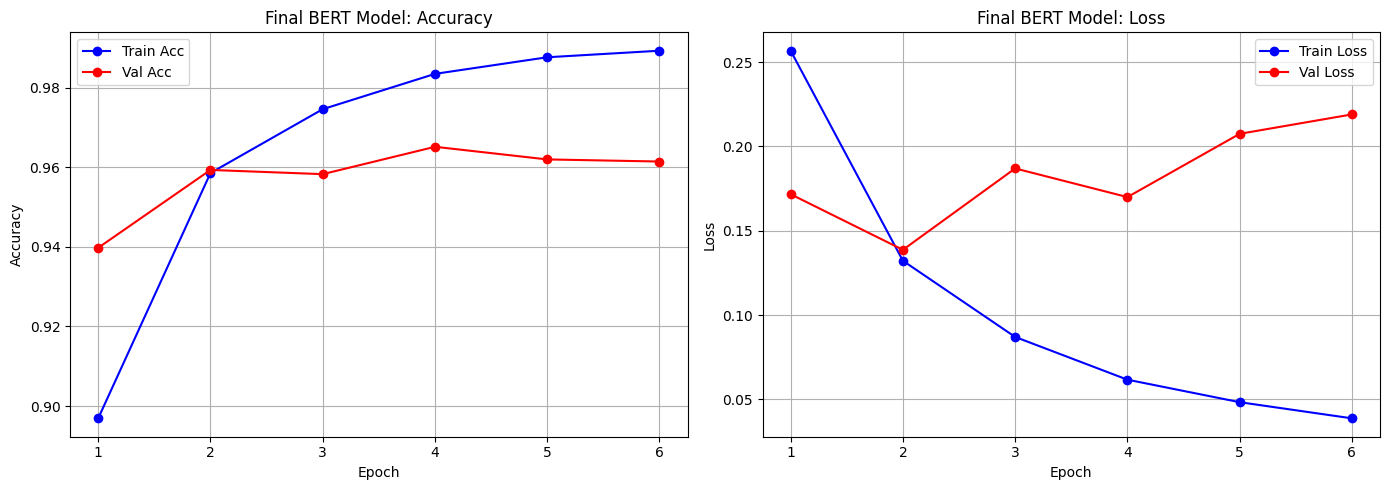


🔍 Evaluating on HELD-OUT TEST SET...


Test Evaluation: 100%|██████████| 171/171 [00:04<00:00, 38.00it/s]



🟩 FINAL TEST RESULTS:
Accuracy : 0.9514
Precision: 0.9632
Recall   : 0.9569
F1-Score : 0.9600

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

No Violation       0.93      0.94      0.94      1066
   Violation       0.96      0.96      0.96      1669

    accuracy                           0.95      2735
   macro avg       0.95      0.95      0.95      2735
weighted avg       0.95      0.95      0.95      2735



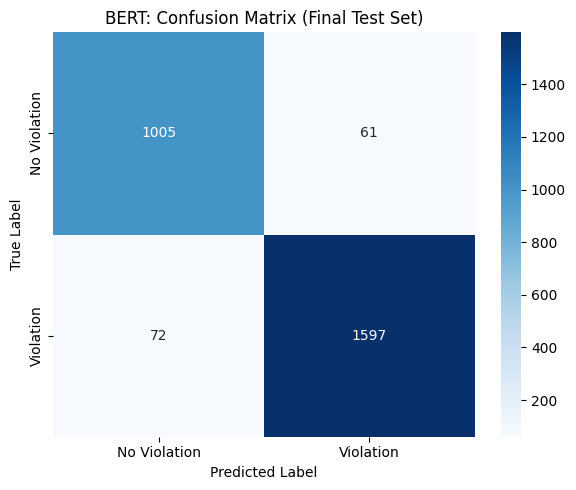

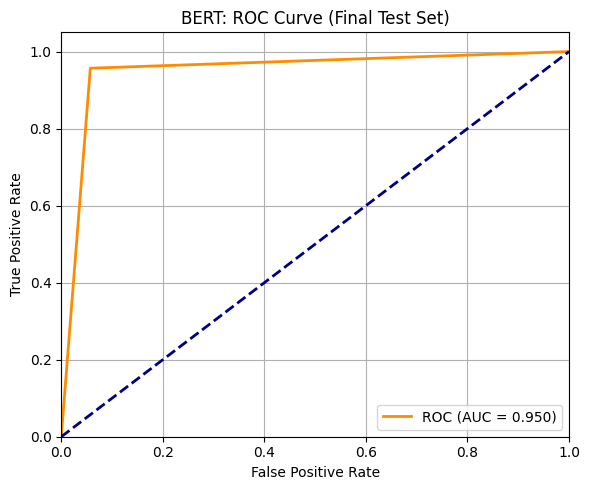

In [6]:
# ----------------------------
# 7. Final Model Training with Internal Val
# ----------------------------
print("\n🎯 Retraining final model on FULL TRAIN...")

ros_full = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros_full.fit_resample(np.array(X_train_raw).reshape(-1, 1), y_train_raw)
X_train_res, y_train_res = X_train_res.flatten().tolist(), y_train_res.tolist()

# Internal val split
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train_res, y_train_res, test_size=0.1, random_state=42, stratify=y_train_res
)

train_dataset = TextClassificationDataset(X_tr_final, y_tr_final, tokenizer, max_length)
val_dataset = TextClassificationDataset(X_val_final, y_val_final, tokenizer, max_length)
test_dataset = TextClassificationDataset(X_test, y_test, tokenizer, max_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

final_model = BERTClassifier(model_name, num_classes).to(device)
optimizer = AdamW(final_model.parameters(), lr=learning_rate)
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

# Track final history
final_train_losses = []
final_train_accs = []
final_val_losses = []
final_val_accs = []

for epoch in range(num_epochs):
    # Train
    final_model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = final_model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    final_train_losses.append(avg_train_loss)
    final_train_accs.append(train_acc)

    # Validate
    final_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = final_model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    final_val_losses.append(avg_val_loss)
    final_val_accs.append(val_acc)

# ----------------------------
# 7b. Final Model Learning Curves
# ----------------------------
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, final_train_accs, 'b-o', label='Train Acc')
plt.plot(epochs, final_val_accs, 'r-o', label='Val Acc')
plt.title('Final BERT Model: Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, final_train_losses, 'b-o', label='Train Loss')
plt.plot(epochs, final_val_losses, 'r-o', label='Val Loss')
plt.title('Final BERT Model: Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig('bert_final_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 8. Final Test Evaluation
# ----------------------------
print("\n🔍 Evaluating on HELD-OUT TEST SET...")
final_model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test Evaluation"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = final_model(input_ids, attention_mask)
        preds = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(test_labels, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='binary')

print(f"\n🟩 FINAL TEST RESULTS:")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\n📋 Classification Report (Test Set):")
print(classification_report(test_labels, test_preds, target_names=["No Violation", "Violation"]))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Violation", "Violation"], yticklabels=["No Violation", "Violation"])
plt.title("BERT: Confusion Matrix (Final Test Set)")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig('bert_final_cm.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('BERT: ROC Curve (Final Test Set)')
plt.legend(loc="lower right"); plt.grid(True)
plt.tight_layout()
plt.savefig('bert_final_roc.png', dpi=300, bbox_inches='tight')
plt.show()